# ML-метрики для предсказания excess return

Цель: оценить, насколько модели действительно **предсказывают** `excess return` и/или знак доходности **по стандартным ML-метрикам** (MSE, \(R^2\), Accuracy, ROC-AUC) на всём универсе.



In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / "data").exists() else CWD.parent
DATASETS_DIR = ROOT / "data" / "datasets"

main_df = pd.read_parquet(DATASETS_DIR / "top3000_data_df.parquet")
presence = pd.read_parquet(DATASETS_DIR / "top3000_presence_matrix.parquet")

print("Loaded:")
print("- main_df:", main_df.shape)
print("- presence:", presence.shape)

In [ ]:
sample_cols = list(main_df.columns[:10])
main_df[sample_cols].head()

,10012,10025,10026,10032,10034,10035,10048,10051,10064,10071,...,quality,seasonality,short_term_reversal,size,value,spx,acc_rate,mkt-rf,spx-rf,spx_fut
date,,,,,,,,,,,,,,,,,,,,,
1979-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000480,0.000872,-0.000514,0.001280,-0.000950,NaN,0.0005,0.0005,NaN,NaN
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.004586,0.001358,0.008195,0.005969,0.010667,NaN,0.0004,-0.0204,NaN,NaN
1980-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.003500,-0.000500,0.003682,-0.004050,0.002117,NaN,0.0004,-0.0073,NaN,NaN
1980-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000111,0.001053,-0.005816,0.001486,-0.005577,NaN,0.0004,0.0132,NaN,NaN
1980-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000279,0.000979,-0.003047,0.000798,-0.001788,NaN,0.0004,0.0039,NaN,NaN


In [ ]:

factors = [
    'acc_rate', 'accruals', 'debt_issuance', 'investment', 'low_leverage', 
    'low_risk', 'mkt-rf', 'momentum', 'profit_growth', 'profitability', 
    'quality', 'seasonality', 'short_term_reversal', 'size', 'value'
]

print(f"Количество используемых макро-факторов: {len(factors)}")

Количество используемых макро-факторов: 15


In [ ]:
tickers = [c for c in main_df.columns if c not in factors]
prices = main_df[tickers]

rf_returns = main_df['acc_rate'].pct_change() 

presence = presence.reindex(index=prices.index, columns=prices.columns)

In [ ]:
sample_tickers = [t for t in prices.columns[:8]]
prices[sample_tickers].head(10)

,10012,10025,10026,10032,10034,10035,10048,10051,10064,10071,...,93423,93426,93428,93429,93430,93433,93436,spx,spx-rf,spx_fut
date,,,,,,,,,,,,,,,,,,,,,
1979-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Фичи

In [ ]:
returns = prices.pct_change()

# --- Базовые волатильности для нормализации (Barroso & Santa-Clara) ---
vol1m = returns.rolling(21).std() * np.sqrt(252)
vol3m = returns.rolling(63).std() * np.sqrt(252)
vol6m = returns.rolling(126).std() * np.sqrt(252)

# Защита от деления на ноль
vol1m_safe = np.where(vol1m < 1e-6, 1e-6, vol1m)
vol3m_safe = np.where(vol3m < 1e-6, 1e-6, vol3m)
vol6m_safe = np.where(vol6m < 1e-6, 1e-6, vol6m)

# --- 1. Нормализованный моментум (Lim et al.) ---
r1m_norm = prices.pct_change(21) / vol1m_safe
r3m_norm = prices.pct_change(63) / vol3m_safe
r6m_norm = prices.pct_change(126) / vol6m_safe
r12m_norm = prices.pct_change(252) / vol6m_safe

# --- 2. Мульти-MACD (Lim et al. / Baz et al.) ---
def get_macd_norm(prices, vol_safe, S, L):
    ema_S = prices.ewm(span=S, adjust=False).mean()
    ema_L = prices.ewm(span=L, adjust=False).mean()
    macd_raw = (ema_S - ema_L) / prices
    return macd_raw / vol_safe

macd_8_24 = get_macd_norm(prices, vol3m_safe, 8, 24)
macd_16_48 = get_macd_norm(prices, vol3m_safe, 16, 48)
macd_32_96 = get_macd_norm(prices, vol3m_safe, 32, 96)


In [ ]:
target_returns = returns.shift(-1)
target_rf = rf_returns.shift(-1)
excess_returns = target_returns.sub(target_rf, axis=0)

import gc

print("Оптимизация сборки: используем numpy массивы для экономии памяти...")

mask_1d = (presence == 1).values.flatten()

dates = presence.index.repeat(presence.shape[1])[mask_1d]

df_ml = pd.DataFrame({
    'r1m_norm': r1m_norm.values.flatten()[mask_1d],
    'r3m_norm': r3m_norm.values.flatten()[mask_1d],
    'r6m_norm': r6m_norm.values.flatten()[mask_1d],
    'r12m_norm': r12m_norm.values.flatten()[mask_1d],
    'macd_8_24': macd_8_24.values.flatten()[mask_1d],
    'macd_16_48': macd_16_48.values.flatten()[mask_1d],
    'macd_32_96': macd_32_96.values.flatten()[mask_1d],
    'vol6m': vol6m.values.flatten()[mask_1d],
    'target_reg': excess_returns.values.flatten()[mask_1d]
}, index=dates)

df_ml = df_ml.astype(np.float32)

gc.collect()

# --- 3. Добавление глобальных факторов ---
print("Добавляем макро-режимы...")
macro_features = main_df[factors].shift(1).astype(np.float32)

# Так как индекс df_ml теперь - это просто даты, обычный join сработает идеально
df_ml = df_ml.join(macro_features)

print("Финальная очистка...")
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)
df_ml.dropna(inplace=True)

# Используем int8 для классификатора (весит почти 0 байт)
df_ml['target_clf'] = (df_ml['target_reg'] > 0).astype(np.int8)

# Обновляем список признаков для Random Forest
new_features = [
    'r1m_norm', 'r3m_norm', 'r6m_norm', 'r12m_norm', 
    'macd_8_24', 'macd_16_48', 'macd_32_96', 'vol6m'
] + factors

print("Готово! Сборка прошла успешно. Размер таблицы:", df_ml.shape)

Оптимизация сборки: используем numpy массивы для экономии памяти...
Добавляем макро-режимы...
Финальная очистка...
Готово! Сборка прошла успешно. Размер таблицы: (11895222, 25)


In [9]:
# =========================================================
# 4. СПЛИТ ДАННЫХ (OUT-OF-TIME)
# =========================================================
# Вытаскиваем даты из мультииндекса (Date, Ticker)
dates = df_ml.index.get_level_values(0)

# Обучаемся на данных ДО 2022 года, тестируем на 2022-2024
# Это заменяет train_test_split и спасает от заглядывания в будущее
train_mask = dates < '2022-01-01'
test_mask = dates >= '2022-01-01'


X_train, X_test = df_ml.loc[train_mask, new_features], df_ml.loc[test_mask, new_features]
y_reg_train, y_reg_test = df_ml.loc[train_mask, 'target_reg'], df_ml.loc[test_mask, 'target_reg']
y_clf_train, y_clf_test = df_ml.loc[train_mask, 'target_clf'], df_ml.loc[test_mask, 'target_clf']

print(f"Размер трейна: {len(X_train)} строк")
print(f"Размер теста: {len(X_test)} строк\n")

Размер трейна: 10385075 строк
Размер теста: 1510147 строк



In [12]:
# =========================================================
# 5. ОБУЧЕНИЕ И ЗАМЕР МЕТРИК
# =========================================================
print("="*40)
print(" ЗАДАЧА 1: РЕГРЕССИЯ (Excess Return)")
print("="*40)

# Бейзлайн: нулевой прогноз
baseline_reg_preds = np.zeros_like(y_reg_test)
baseline_mse = mean_squared_error(y_reg_test, baseline_reg_preds)

# Линейная регрессия
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)
ml_reg_preds = lin_reg.predict(X_test)

ml_mse = mean_squared_error(y_reg_test, ml_reg_preds)
ml_r2 = r2_score(y_reg_test, ml_reg_preds)

print(f"Бейзлайн MSE: {baseline_mse:.6f}")
print(f"LinReg MSE:   {ml_mse:.6f}")
print(f"LinReg R2:    {ml_r2:.6f}")

print("\n" + "="*40)
print(" ЗАДАЧА 2: КЛАССИФИКАЦИЯ (Направление)")
print("="*40)

# Бейзлайн: всегда ставим на самый частый класс
majority_class = y_clf_train.mode()[0]
baseline_clf_preds = np.full_like(y_clf_test, majority_class)
baseline_acc = accuracy_score(y_clf_test, baseline_clf_preds)

# Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_clf_train)
ml_clf_preds = log_reg.predict(X_test)

ml_acc = accuracy_score(y_clf_test, ml_clf_preds)

print(f"Бейзлайн Acc: {baseline_acc:.4f}")
print(f"LogReg Acc:   {ml_acc:.4f}")

 ЗАДАЧА 1: РЕГРЕССИЯ (Excess Return)
Бейзлайн MSE: 0.002784
LinReg MSE:   0.002783
LinReg R2:    -0.000412

 ЗАДАЧА 2: КЛАССИФИКАЦИЯ (Направление)
Бейзлайн Acc: 0.5062
LogReg Acc:   0.5110


In [17]:
from sklearn.linear_model import Ridge
import numpy as np

print("="*40)
print(" ЗАДАЧА 1: РЕГРЕССИЯ (Robust Excess Return)")
print("="*40)

# 1. Обрезка выбросов (Winsorization) на обучающей выборке
# Мы обрезаем таргет по 1-му и 99-му перцентилям. 
# Это не даст сверх-аномалиям сломать веса модели.
lower_bound = y_reg_train.quantile(0.01)
upper_bound = y_reg_train.quantile(0.99)

y_reg_train_clipped = y_reg_train.clip(lower=lower_bound, upper=upper_bound)

# ВАЖНО: Тестовую выборку мы НЕ обрезаем, мы должны честно оценивать 
# предсказания на реальных, "грязных" рыночных данных.

# Бейзлайн: нулевой прогноз
baseline_reg_preds = np.zeros_like(y_reg_test)
baseline_mse = mean_squared_error(y_reg_test, baseline_reg_preds)

# 2. Ridge Regression (L2-регуляризация)
# alpha=100.0 или даже 1000.0 — в финансах нужна очень сильная регуляризация
ridge_reg = Ridge(alpha=100.0, random_state=42)
ridge_reg.fit(X_train, y_reg_train_clipped)

ml_reg_preds = ridge_reg.predict(X_test)

ml_mse = mean_squared_error(y_reg_test, ml_reg_preds)
ml_r2 = r2_score(y_reg_test, ml_reg_preds)

print(f"Бейзлайн MSE:  {baseline_mse:.6f}")
print(f"Ridge MSE:     {ml_mse:.6f}")
print(f"Ridge R2:      {ml_r2:.6f}")

# Для наглядности посмотрим на веса, которые выучила модель
weights = pd.Series(ridge_reg.coef_, index=X_train.columns).sort_values()
print("\nВеса модели (Ridge Coefficients):")
print(weights.head(3)) # Топ негативных
print(weights.tail(3)) # Топ позитивных

 ЗАДАЧА 1: РЕГРЕССИЯ (Robust Excess Return)
Бейзлайн MSE:  0.002784
Ridge MSE:     0.002783
Ridge R2:      -0.000137

Веса модели (Ridge Coefficients):
macd_16_48     -0.008807
seasonality    -0.006150
low_leverage   -0.006036
dtype: float32
momentum         0.047700
profit_growth    0.055871
low_risk         0.069652
dtype: float32


/Users/tdavi/Desktop/Se/ml studying/deep-momentum/deep_venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.9127642178484727e-11.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


# --- РЕГРЕССИЯ ---
# max_depth=5 чтобы не переобучиться на шуме
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
ml_reg_preds = rf_reg.predict(X_test)

ml_mse = mean_squared_error(y_reg_test, ml_reg_preds)
ml_r2 = r2_score(y_reg_test, ml_reg_preds)

print(f"RandomForest MSE: {ml_mse:.6f}")
print(f"RandomForest R2:  {ml_r2:.6f}")

# --- КЛАССИФИКАЦИЯ ---
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_clf_train)
ml_clf_preds = rf_clf.predict(X_test)

ml_acc = accuracy_score(y_clf_test, ml_clf_preds)

print(f"RandomForest Acc: {ml_acc:.4f}")


Обучаем Random Forest (это займет пару минут)...
RandomForest MSE: 0.002805
RandomForest R2:  -0.003422
RandomForest Acc: 0.5066


Обучаем строго регуляризованный Random Forest...
Tuned RF Regressor MSE: 0.002788
Tuned RF Regressor R2:  -0.002231
Tuned RF Classifier Acc: 0.5091

Анализ важности признаков (Feature Importances):
      Feature  Importance
       mkt-rf    0.148392
          spx    0.135565
         size    0.111392
       spx-rf    0.101947
        value    0.088953
     low_risk    0.075730
     accruals    0.069677
   investment    0.042964
profit_growth    0.038013
      spx_fut    0.034810


/var/folders/_k/6qmryt657x530hyp1jvb0ck00000gn/T/ipykernel_64023/649090207.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(12), x='Importance', y='Feature', palette='viridis')


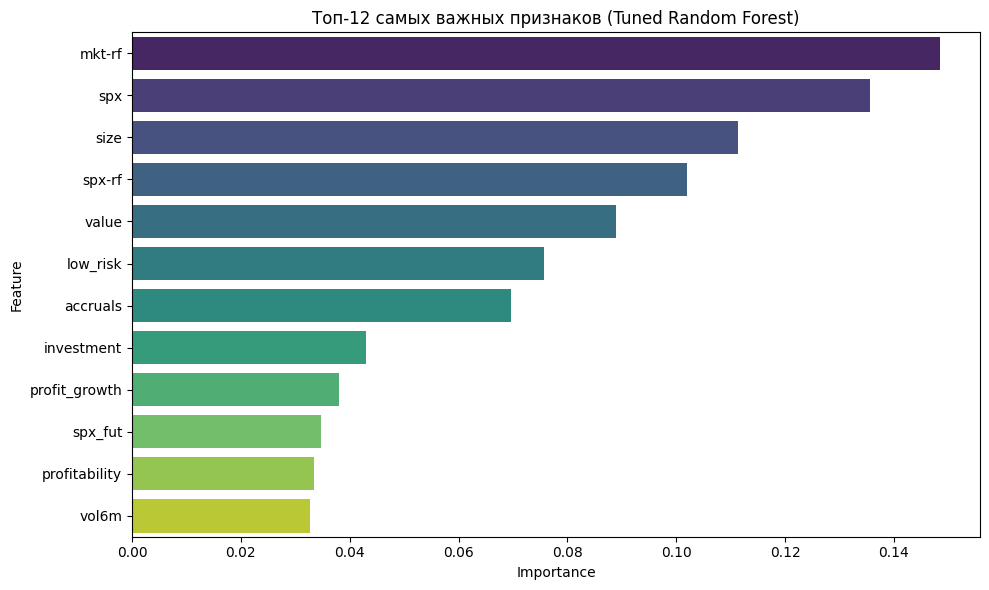

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("Обучаем строго регуляризованный Random Forest...")

# --- РЕГРЕССИЯ ---
rf_reg_tuned = RandomForestRegressor(
    n_estimators=200, 
    max_depth=3,              # Строго ограничиваем глубину
    min_samples_leaf=2000,    # Огромный размер листа для защиты от выбросов
    max_features='sqrt',      # Декоррелируем деревья
    random_state=42, 
    n_jobs=4
)

rf_reg_tuned.fit(X_train, y_reg_train)
ml_reg_preds = rf_reg_tuned.predict(X_test)

ml_mse = mean_squared_error(y_reg_test, ml_reg_preds)
ml_r2 = r2_score(y_reg_test, ml_reg_preds)

print(f"Tuned RF Regressor MSE: {ml_mse:.6f}")
print(f"Tuned RF Regressor R2:  {ml_r2:.6f}")

# --- КЛАССИФИКАЦИЯ ---
rf_clf_tuned = RandomForestClassifier(
    n_estimators=200, 
    max_depth=3, 
    min_samples_leaf=2000, 
    max_features='sqrt', 
    random_state=42, 
    n_jobs=4
)

rf_clf_tuned.fit(X_train, y_clf_train)
ml_clf_preds = rf_clf_tuned.predict(X_test)
ml_acc = accuracy_score(y_clf_test, ml_clf_preds)

print(f"Tuned RF Classifier Acc: {ml_acc:.4f}\n")

print("Анализ важности признаков (Feature Importances):")

importances = rf_clf_tuned.feature_importances_
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(fi_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(12), x='Importance', y='Feature', palette='viridis')
plt.title('Топ-12 самых важных признаков (Tuned Random Forest)')
plt.tight_layout()
plt.show()

Обучаем строго регуляризованный Random Forest...
Tuned RF Regressor MSE: 0.002786
Tuned RF Regressor R2:  -0.001411
Tuned RF Classifier Acc: 0.5057

Анализ важности признаков (Feature Importances):
      Feature  Importance
     acc_rate    0.182415
     low_risk    0.131635
         size    0.089022
       mkt-rf    0.088575
        value    0.071451
     momentum    0.069444
debt_issuance    0.064364
 low_leverage    0.051781
     accruals    0.047463
profitability    0.039515


/var/folders/_k/6qmryt657x530hyp1jvb0ck00000gn/T/ipykernel_65076/649090207.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(12), x='Importance', y='Feature', palette='viridis')


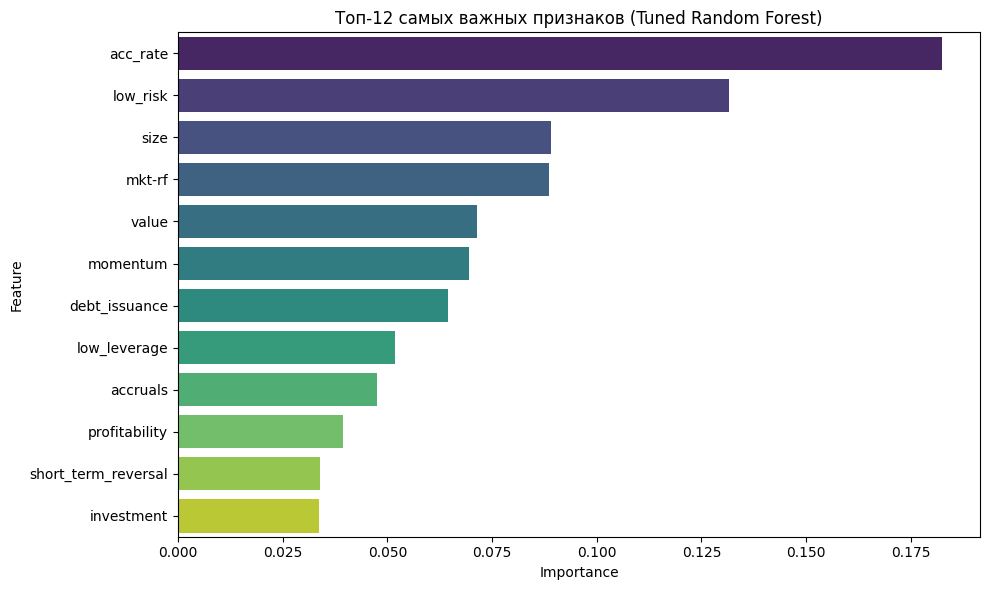

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

rf_reg_tuned = RandomForestRegressor(
    n_estimators=200, 
    max_depth=3,  
    min_samples_leaf=2000,
    max_features='sqrt',      
    random_state=42, 
    n_jobs=4
)

rf_reg_tuned.fit(X_train, y_reg_train)
ml_reg_preds = rf_reg_tuned.predict(X_test)

ml_mse = mean_squared_error(y_reg_test, ml_reg_preds)
ml_r2 = r2_score(y_reg_test, ml_reg_preds)

print(f"Tuned RF Regressor MSE: {ml_mse:.6f}")
print(f"Tuned RF Regressor R2:  {ml_r2:.6f}")
-
rf_clf_tuned = RandomForestClassifier(
    n_estimators=200, 
    max_depth=3, 
    min_samples_leaf=2000, 
    max_features='sqrt', 
    random_state=42, 
    n_jobs=4
)

rf_clf_tuned.fit(X_train, y_clf_train)
ml_clf_preds = rf_clf_tuned.predict(X_test)
ml_acc = accuracy_score(y_clf_test, ml_clf_preds)

print(f"Tuned RF Classifier Acc: {ml_acc:.4f}\n")


importances = rf_clf_tuned.feature_importances_
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


print(fi_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(12), x='Importance', y='Feature', palette='viridis')
plt.title('Топ-12 самых важных признаков (Tuned Random Forest)')
plt.tight_layout()
plt.show()

In [ ]:
stock_specific_features = [
    'r1m_norm', 'r3m_norm', 'r6m_norm', 'r12m_norm', 
    'macd_8_24', 'macd_16_48', 'macd_32_96', 'vol6m'
]

X_train_rf = X_train[stock_specific_features]
X_test_rf = X_test[stock_specific_features]

print("Обучаем Random Forest только на специфичных фичах акций...")
rf_clf_stock = RandomForestClassifier(
    n_estimators=200, 
    max_depth=4,              
    min_samples_leaf=1000, 
    random_state=42, 
    n_jobs=4
)
rf_clf_stock.fit(X_train_rf, y_clf_train)
ml_acc_stock = accuracy_score(y_clf_test, rf_clf_stock.predict(X_test_rf))

print(f"Stock-Specific RF Acc: {ml_acc_stock:.4f}")

# Посмотрим, что теперь в топе:
fi_stock = pd.Series(rf_clf_stock.feature_importances_, index=stock_specific_features).sort_values(ascending=False)
print("\nНовые Feature Importances:")
print(fi_stock)

Обучаем Random Forest только на специфичных фичах акций...
Stock-Specific RF Acc: 0.5062

Новые Feature Importances:
vol6m         0.281808
r12m_norm     0.245092
macd_8_24     0.163938
macd_32_96    0.112830
r1m_norm      0.085325
macd_16_48    0.056175
r6m_norm      0.030724
r3m_norm      0.024108
dtype: float64


: 